In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

tx = pd.read_csv("../data/raw/train_transaction.csv")
idn = pd.read_csv("../data/raw/train_identity.csv")


In [3]:
tx.shape, idn.shape


((590540, 394), (144233, 41))

In [4]:
tx.head()
tx.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [5]:
tx.columns


Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)

so here i work on column and make report the column ,where the column used-
1.isfraud - used as target/label
2.TransactionID - identifier (not feature) - only used for join ,tracking
3.'TransactionDT','TransactionAmt','ProductCD','card1','card6','addr1', 'addr2' - very imp bcz anamoly start here - Primary Signals
4.V1-V339 - behaviour enginerred feature - V-features are pre-engineered behavioral signals; I selectively include them based on statistical usefulness, stability, and missingness when we use this -Anomaly is subtle,Pattern is multi-dimensional,Core features alone are insufficient


In [6]:
y = tx["isFraud"]
tx = tx.drop(columns=["isFraud"])


In [7]:
missing = tx.isnull().mean().sort_values(ascending=False)
missing.head(20)


dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D8       0.873123
D9       0.873123
V153     0.861237
V149     0.861237
V141     0.861237
V146     0.861237
V154     0.861237
V162     0.861237
V142     0.861237
V158     0.861237
V161     0.861237
V157     0.861237
V138     0.861237
V139     0.861237
dtype: float64

In [8]:
missing.describe()


count    393.000000
mean       0.411779
std        0.358817
min        0.000000
25%        0.002149
50%        0.286126
75%        0.779134
max        0.936284
dtype: float64

In [9]:
THRESHOLD = 0.9  

keep_cols = missing[missing < THRESHOLD].index
tx_reduced = tx[keep_cols]


We drop columns that have more than 90% missing values because they are mostly empty and not useful for learning

In [10]:
tx.shape, tx_reduced.shape


((590540, 393), (590540, 391))

In [11]:
card_cols = [
    "card1", "card2", "card3", "card4", "card5", "card6"
]

eda_cols = [
    "TransactionDT",
    "TransactionAmt",
    "addr1",
    "addr2"
] + card_cols

tx_core = tx[eda_cols]


In [12]:
tx_core.isnull().mean().sort_values()

TransactionDT     0.000000
TransactionAmt    0.000000
card1             0.000000
card3             0.002650
card6             0.002660
card4             0.002670
card5             0.007212
card2             0.015127
addr1             0.111264
addr2             0.111264
dtype: float64

In [13]:
tx_core.describe(include="all")


,TransactionDT,TransactionAmt,addr1,addr2,card1,card2,card3,card4,card5,card6
count,5.905400e+05,590540.000000,524834.000000,524834.000000,590540.000000,581607.000000,588975.000000,588963,586281.000000,588969
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,visa,NaN,debit
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,384767,NaN,439938
mean,7.372311e+06,135.027176,290.733794,86.800630,9898.734658,362.555488,153.194925,NaN,199.278897,NaN
std,4.617224e+06,239.162522,101.741072,2.690623,4901.170153,157.793246,11.336444,NaN,41.244453,NaN
min,8.640000e+04,0.251000,100.000000,10.000000,1000.000000,100.000000,100.000000,NaN,100.000000,NaN
25%,3.027058e+06,43.321000,204.000000,87.000000,6019.000000,214.000000,150.000000,NaN,166.000000,NaN
50%,7.306528e+06,68.769000,299.000000,87.000000,9678.000000,361.000000,150.000000,NaN,226.000000,NaN
75%,1.124662e+07,125.000000,330.000000,87.000000,14184.000000,512.000000,150.000000,NaN,226.000000,NaN


In [14]:
missing_pct = tx_core.isnull().mean() * 100

missing_pct.sort_values(ascending=False).head(10)


addr2             11.126427
addr1             11.126427
card2              1.512683
card5              0.721204
card4              0.267044
card6              0.266028
card3              0.265012
TransactionDT      0.000000
TransactionAmt     0.000000
card1              0.000000
dtype: float64

In [15]:
tx_core[card_cols].nunique()


card1    13553
card2      500
card3      114
card4        4
card5      119
card6        4
dtype: int64

In [16]:
base_features = [
    "TransactionDT",
    "TransactionAmt",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2"
]


In [17]:
tx_feat = tx[base_features].copy()


In [18]:
numeric_cols = ["TransactionAmt"]

tx_feat[numeric_cols] = tx_feat[numeric_cols].fillna(0)


In [19]:
low_cat = ["card3", "card4", "card6", "addr2"]

for col in low_cat:
    tx_feat[col] = tx_feat[col].fillna("Unknown")


In [20]:
high_cat = ["card1", "card2", "card5", "addr1"]

for col in high_cat:
    tx_feat[f"{col}_missing"] = tx_feat[col].isnull().astype(int)


In [21]:
tx_feat.isnull().mean().sort_values()


TransactionDT     0.000000
TransactionAmt    0.000000
card1             0.000000
card3             0.000000
card6             0.000000
card4             0.000000
card1_missing     0.000000
addr2             0.000000
addr1_missing     0.000000
card5_missing     0.000000
card2_missing     0.000000
card5             0.007212
card2             0.015127
addr1             0.111264
dtype: float64

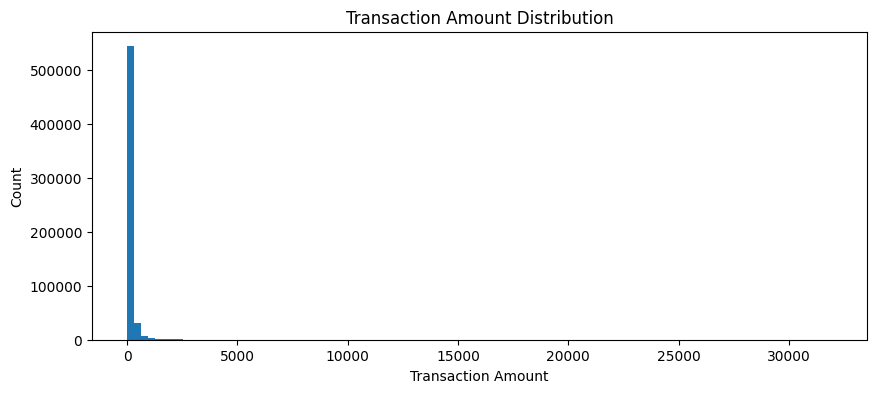

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,4))
plt.hist(tx_feat["TransactionAmt"], bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.show()


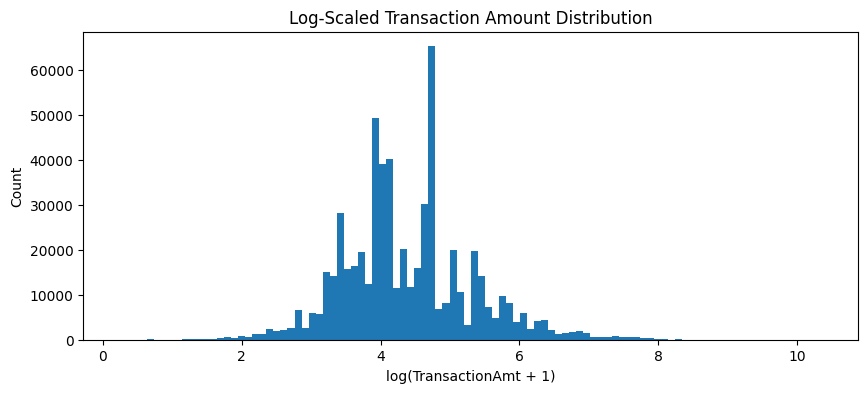

In [23]:
plt.figure(figsize=(10,4))
plt.hist(np.log1p(tx_feat["TransactionAmt"]), bins=100)
plt.title("Log-Scaled Transaction Amount Distribution")
plt.xlabel("log(TransactionAmt + 1)")
plt.ylabel("Count")
plt.show()


<Figure size 800x400 with 0 Axes>

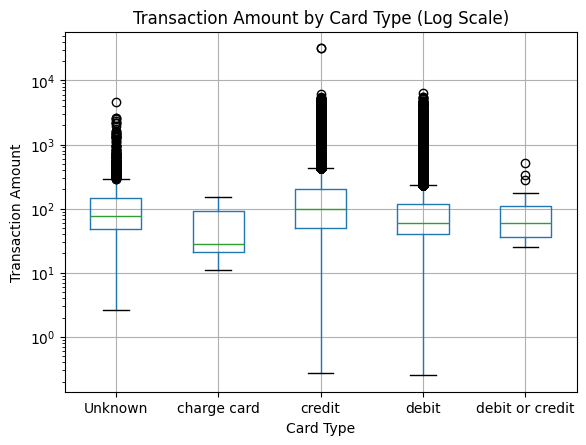

In [24]:
plt.figure(figsize=(8,4))
tx_feat.boxplot(column="TransactionAmt", by="card6")
plt.yscale("log")
plt.title("Transaction Amount by Card Type (Log Scale)")
plt.suptitle("")
plt.xlabel("Card Type")
plt.ylabel("Transaction Amount")
plt.show()


In [25]:
card_agg = (
    tx_feat
    .groupby("card1")["TransactionAmt"]
    .agg(
        card_tx_count="count",
        card_amt_mean="mean",
        card_amt_std="std",
        card_amt_max="max"
    )
    .reset_index()
)

tx_feat = tx_feat.merge(card_agg, on="card1", how="left")


In [26]:
tx_feat["amt_over_card_mean"] = (
    tx_feat["TransactionAmt"] / (tx_feat["card_amt_mean"] + 1e-5)
)

tx_feat["amt_minus_card_mean"] = (
    tx_feat["TransactionAmt"] - tx_feat["card_amt_mean"]
)


In [27]:
agg_cols = [
    "card_amt_mean",
    "card_amt_std",
    "card_amt_max",
    "card_tx_count"
]

tx_feat[agg_cols] = tx_feat[agg_cols].fillna(0)


In [28]:
X = tx_feat.drop(columns=["TransactionDT"])


In [29]:
X.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
TransactionAmt,1.350272e+02,239.162522,0.251000,31937.391000
card1,9.898735e+03,4901.170153,1000.000000,18396.000000
card2,3.625555e+02,157.793246,100.000000,600.000000
card5,1.992789e+02,41.244453,100.000000,237.000000
addr1,2.907338e+02,101.741072,100.000000,540.000000
card1_missing,0.000000e+00,0.000000,0.000000,0.000000
card2_missing,1.512683e-02,0.122058,0.000000,1.000000
card5_missing,7.212043e-03,0.084617,0.000000,1.000000
addr1_missing,1.112643e-01,0.314459,0.000000,1.000000
card_tx_count,2.528815e+03,3702.655513,1.000000,14932.000000


In [30]:
X.shape
X.isnull().sum().sum()



np.int64(78898)

In [31]:
tx_feat = tx_feat.sort_values("TransactionDT")


In [32]:
tx_feat["time_since_last_tx"] = (
    tx_feat.groupby("card1")["TransactionDT"]
    .diff()
    .fillna(999999)
)


In [33]:
tx_feat["day"] = tx_feat["TransactionDT"] // (3600 * 24)

tx_feat["tx_per_card_per_day"] = (
    tx_feat.groupby(["card1", "day"])["TransactionAmt"]
    .transform("count")
)


In [34]:
tx_feat["hour"] = (tx_feat["TransactionDT"] // 3600) % 24


In [35]:
time_cols = ["time_since_last_tx", "tx_per_card_per_day"]

tx_feat[time_cols] = tx_feat[time_cols].fillna(0)


In [36]:
model_features = [
    "TransactionAmt",
    "card_tx_count",
    "card_amt_mean",
    "card_amt_std",
    "card_amt_max",
    "amt_over_card_mean",
    "amt_minus_card_mean",
    "time_since_last_tx",
    "tx_per_card_per_day",
    "card2_missing",
    "card5_missing",
    "addr1_missing"
]


In [37]:
X = tx_feat[model_features].copy()


In [38]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


In [39]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,  
    random_state=42
)

iso.fit(X_scaled)


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [40]:
tx_feat["anomaly_score"] = -iso.decision_function(X_scaled)


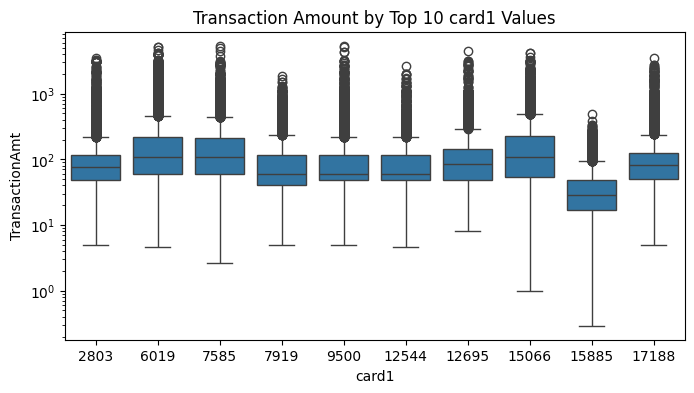

In [41]:
import seaborn as sns
top_cards = tx["card1"].value_counts().head(10).index

plt.figure(figsize=(8,4))
sns.boxplot(
    data=tx[tx["card1"].isin(top_cards)],
    x="card1",
    y="TransactionAmt"
)
plt.yscale("log")
plt.title("Transaction Amount by Top 10 card1 Values")
plt.show()


In [42]:
import pandas as pd

pd.crosstab(
    tx_feat["anomaly_score"] > tx_feat["anomaly_score"].quantile(0.98),
    y,
    normalize='index'
)


isFraud,0,1
anomaly_score,,
False,0.965232,0.034768
True,0.954111,0.045889


In [43]:
thresholds = [0.995, 0.99, 0.98]

for t in thresholds:
    flagged = tx_feat["anomaly_score"] > tx_feat["anomaly_score"].quantile(t)
    fraud_rate = y[flagged].mean()
    print(f"Threshold {t}: Alerts={flagged.sum()}, FraudRate={fraud_rate:.4f}")


Threshold 0.995: Alerts=2953, FraudRate=0.0240
Threshold 0.99: Alerts=5904, FraudRate=0.0283
Threshold 0.98: Alerts=11811, FraudRate=0.0459


In [44]:
tx_feat = tx_feat.sort_values("TransactionDT")

tx_feat["tx_count_last_10min"] = (
    tx_feat.groupby("card1")["TransactionDT"]
    .transform(lambda x: x.rolling(10, min_periods=1).count())
)


In [45]:
tx_feat["tx_count_last_10min"] = tx_feat["tx_count_last_10min"].fillna(1)


In [46]:
model_features.append("tx_count_last_10min")

X = tx_feat[model_features]

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.ensemble import IsolationForest
iso = IsolationForest(
    n_estimators=300,
    max_samples=0.8,
    contamination=0.02,
    random_state=42
)

iso.fit(X_scaled)

tx_feat["anomaly_score"] = -iso.decision_function(X_scaled)


In [47]:
pd.crosstab(
    tx_feat["anomaly_score"] > tx_feat["anomaly_score"].quantile(0.99),
    y,
    normalize="index"
)


isFraud,0,1
anomaly_score,,
False,0.965332,0.034668
True,0.933119,0.066881


In [48]:
q_high = tx_feat["anomaly_score"].quantile(0.995)
q_med  = tx_feat["anomaly_score"].quantile(0.98)
q_low  = tx_feat["anomaly_score"].quantile(0.95)


In [49]:
def assign_alert(score):
    if score >= q_high:
        return "HIGH"
    elif score >= q_med:
        return "MEDIUM"
    elif score >= q_low:
        return "LOW"
    else:
        return "NONE"

tx_feat["alert_tier"] = tx_feat["anomaly_score"].apply(assign_alert)


In [50]:
tx_eval = tx_feat.copy()
tx_eval["isFraud"] = y.values


In [51]:
tx_eval.groupby("alert_tier")["isFraud"].agg(
    count="count",
    fraud_rate="mean"
)


,count,fraud_rate
alert_tier,,
HIGH,2953,0.049441
LOW,17716,0.039117
MEDIUM,8858,0.059720
NONE,561013,0.034393


In [52]:
tx_feat["reason_high_amount"] = tx_feat["amt_over_card_mean"] > 3

tx_feat["reason_high_velocity"] = (
    tx_feat["tx_per_card_per_day"] > tx_feat["tx_per_card_per_day"].quantile(0.99)
)

tx_feat["reason_rapid_tx"] = tx_feat["time_since_last_tx"] < 60  

tx_feat["reason_missing_identity"] = (
    tx_feat["addr1_missing"] |
    tx_feat["card2_missing"] |
    tx_feat["card5_missing"]
)


In [53]:
def explain_row(row):
    reasons = []
    if row["reason_high_amount"]:
        reasons.append("Amount unusually high for this card")
    if row["reason_high_velocity"]:
        reasons.append("High transaction frequency")
    if row["reason_rapid_tx"]:
        reasons.append("Transactions happening too quickly")
    if row["reason_missing_identity"]:
        reasons.append("Incomplete identity information")
    return "; ".join(reasons)

tx_feat["explanation"] = tx_feat.apply(explain_row, axis=1)


In [54]:
tx_feat[tx_feat["alert_tier"] == "HIGH"]["explanation"].value_counts().head(10)


explanation
Incomplete identity information                                                                        1267
Amount unusually high for this card                                                                     588
                                                                                                        475
Amount unusually high for this card; Incomplete identity information                                    371
Amount unusually high for this card; High transaction frequency                                          66
Transactions happening too quickly; Incomplete identity information                                      40
Amount unusually high for this card; High transaction frequency; Transactions happening too quickly      35
High transaction frequency                                                                               33
Amount unusually high for this card; Transactions happening too quickly                                  26
High transaction

Supervised_learning

In [55]:
risk_df = tx_feat[tx_feat["alert_tier"].isin(["HIGH", "MEDIUM"])].copy()
risk_df["isFraud"] = y.loc[risk_df.index].values


In [56]:
supervised_features = [
    "TransactionAmt",
    "amt_over_card_mean",
    "tx_per_card_per_day",
    "time_since_last_tx",
    "tx_count_last_10min",
    "card2_missing",
    "card5_missing",
    "addr1_missing"
]

X_sup = risk_df[supervised_features]
y_sup = risk_df["isFraud"]


In [57]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

lgb.fit(X_sup, y_sup)


[LightGBM] [Info] Number of positive: 675, number of negative: 11136
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 930
[LightGBM] [Info] Number of data points in the train set: 11811, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [59]:
risk_df["fraud_prob"] = lgb.predict_proba(X_sup)[:, 1]

risk_df.sort_values("fraud_prob", ascending=False).head(20)[
    ["fraud_prob", "alert_tier", "explanation", "isFraud"]
]


,fraud_prob,alert_tier,explanation,isFraud
255431,0.995780,MEDIUM,Incomplete identity information,1
254726,0.995385,MEDIUM,Incomplete identity information,1
231386,0.995165,MEDIUM,Incomplete identity information,1
257065,0.995165,MEDIUM,Incomplete identity information,1
245857,0.995050,MEDIUM,Incomplete identity information,1
255909,0.995029,MEDIUM,Incomplete identity information,1
255373,0.995023,MEDIUM,Incomplete identity information,1
255527,0.995023,MEDIUM,Incomplete identity information,1
255474,0.995023,MEDIUM,Incomplete identity information,1
255696,0.994679,MEDIUM,Incomplete identity information,1


In [60]:
tx_full = tx.merge(idn, on="TransactionID", how="left")
tx_export = tx_full.copy()


In [61]:
engineered_cols = [
    "card_tx_count",
    "card_amt_mean",
    "amt_over_card_mean",
    "time_since_last_tx",
    "tx_per_card_per_day",
    "card2_missing",
    "card5_missing",
    "addr1_missing",
    "anomaly_score"
]

tx_export[engineered_cols] = tx_feat[engineered_cols]


In [62]:


# 1️⃣ Start from identifiers + base business fields
tx_export = tx_feat.copy()

# 2️⃣ Reattach label explicitly (THIS FIXES YOUR ERROR)
tx_export["isFraud"] = y.values

# 3️⃣ Reattach TransactionID safely
tx_export["TransactionID"] = tx_full["TransactionID"].values

# 4️⃣ Select final columns (only if they exist)
final_cols = [
    "TransactionID",
    "isFraud",
    "TransactionAmt",
    "card_tx_count",
    "card_amt_mean",
    "amt_over_card_mean",
    "time_since_last_tx",
    "tx_per_card_per_day",
    "card2_missing",
    "card5_missing",
    "addr1_missing",
    "anomaly_score"
]

final_cols = [c for c in final_cols if c in tx_export.columns]

# 5️⃣ Save
tx_export[final_cols].to_csv(
    "../data/processed/tx_feat.csv",
    index=False
)

print("✅ Final dataset saved successfully — notebook complete")


✅ Final dataset saved successfully — notebook complete


In [63]:
import pandas as pd

df = pd.read_csv("../data/processed/tx_feat.csv")

print(df["isFraud"].mean())
print(df.describe())


0.03499000914417313
       TransactionID        isFraud  TransactionAmt  card_tx_count  \
count   5.905400e+05  590540.000000   590540.000000  590540.000000   
mean    3.282270e+06       0.034990      135.027176    2528.815464   
std     1.704744e+05       0.183755      239.162522    3702.655513   
min     2.987000e+06       0.000000        0.251000       1.000000   
25%     3.134635e+06       0.000000       43.321000     132.000000   
50%     3.282270e+06       0.000000       68.769000     919.000000   
75%     3.429904e+06       0.000000      125.000000    3152.000000   
max     3.577539e+06       1.000000    31937.391000   14932.000000   

       card_amt_mean  amt_over_card_mean  time_since_last_tx  \
count  590540.000000       590540.000000        5.905400e+05   
mean      135.027176            1.000000        1.894693e+05   
std        79.283325            1.366219        7.092351e+05   
min         0.615000            0.002787        0.000000e+00   
25%        97.863769         

In [64]:
!pip install mlflow


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [65]:
!pip install "mlflow[extras]"


Defaulting to user installation because normal site-packages is not writeable
  Using cached requests_auth_aws_sigv4-0.7-py3-none-any.whl.metadata (5.5 kB)
  Using cached boto3-1.42.44-py3-none-any.whl.metadata (6.8 kB)
  Using cached botocore-1.42.44-py3-none-any.whl.metadata (5.9 kB)
  Using cached google_cloud_storage-3.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached azureml_core-1.61.0.post1-py3-none-any.whl.metadata (3.5 kB)
  Using cached pysftp-0.2.9.tar.gz (25 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached kubernetes-35.0.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached virtualenv-20.36.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached prometheus_flask_exporter-0.23.2

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import mlflow
import mlflow.sklearn

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline.fit(X, y)

mlflow.sklearn.log_model(pipeline, "model")


[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013011 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2165
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076


2026/02/09 14:40:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/09 14:40:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/09 14:40:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/09 14:40:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/09 14:40:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/09 14:40:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/09 14:40:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/09 14:40:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/09 14:40:12 INFO mlflow.store.db.utils: Updating database tables
2026/02/09 14:40:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/09 14:40:12 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/09

In [ ]:
df =X  # or df = training_df


In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import mlflow.sklearn

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", lgb.LGBMClassifier(
        objective="binary",
        is_unbalance=True
    ))
])

pipeline.fit(X, y)

mlflow.sklearn.log_model(
    pipeline,
    name="fraud_model"
)


[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2167
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076


c:\Users\tyagi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
